# Задача 5. Классификация: CC50 выше медианы

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src import data_utils as du  # noqa: E402
from src import modeling as mdl  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path.cwd().parent / "reports" / "figures"
RES_DIR = Path.cwd().parent / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных

In [2]:
features, targets, groups, clean_report = du.load_dataset()
target = targets["cc50_gt_median"]

print(f"Признаков: {features.shape[1]}, объектов: {features.shape[0]}")
print(f"Целевая переменная: CC50 > медианы выборки (411.04 mM)")
print(f"Класс 1: {int(target.sum())} объектов ({target.mean():.1%})")
print(f"Класс 0: {int((1 - target).sum())} объектов ({1 - target.mean():.1%})")

Признаков: 178, объектов: 1001
Целевая переменная: CC50 > медианы выборки (411.04 mM)
Класс 1: 499 объектов (49.9%)
Класс 0: 502 объектов (50.1%)


## 2. Разбиение на обучение и отложенный тест
тоже самое что и в 5 задаче

In [3]:
X_train, X_test, y_train, y_test, groups_train = mdl.group_train_test_split(
    features, target, groups
)
train_groups = set(groups[np.isin(features.index, X_train.index)])
test_groups = set(groups[np.isin(features.index, X_test.index)])

print(f"train: {X_train.shape[0]} объектов, доля класса 1 = {y_train.mean():.3f}")
print(f"test:  {X_test.shape[0]} объектов, доля класса 1 = {y_test.mean():.3f}")
print(f"Пересечение групп train/test: {len(train_groups & test_groups)}")

train: 798 объектов, доля класса 1 = 0.494
test:  203 объектов, доля класса 1 = 0.517
Пересечение групп train/test: 0


## 3. Подбор гиперпараметров и сравнение моделей

Восемь моделей: baseline, L1/L2-регрессия, kNN, SVC, четыре ансамбля. Для взвешиваемых class_weight. Метрика ROC-AUC на групповой кросс-валидации

In [4]:
cv_table, fitted = mdl.search_candidates(
    mdl.classification_candidates(), X_train, y_train, groups_train,
    scoring="roc_auc", stratified=True, task="cc50_clf",
)
display(cv_table.drop(columns=["комментарий"]).round(4))

Baseline (частый класс)  CV roc_auc =  0.5000 (±0.0000)
Logistic Regression      CV roc_auc =  0.7949 (±0.0161)
kNN                      CV roc_auc =  0.8113 (±0.0241)


SVC (RBF)                CV roc_auc =  0.8146 (±0.0256)


Random Forest            CV roc_auc =  0.8251 (±0.0161)


Extra Trees              CV roc_auc =  0.8310 (±0.0191)


LightGBM                 CV roc_auc =  0.8213 (±0.0121)


XGBoost                  CV roc_auc =  0.8206 (±0.0167)


,модель,CV roc_auc,std,лучшие гиперпараметры,число обучений
0,Extra Trees,0.8310,0.0191,"{'class_weight': None, 'max_depth': 22, 'max_f...",150
1,Random Forest,0.8251,0.0161,"{'class_weight': 'balanced', 'max_depth': 24, ...",150
2,LightGBM,0.8213,0.0121,"{'class_weight': None, 'colsample_bytree': 0.5...",150
3,XGBoost,0.8206,0.0167,"{'colsample_bytree': 0.77461, 'learning_rate':...",150
4,SVC (RBF),0.8146,0.0256,"{'C': 0.83864, 'class_weight': 'balanced', 'ga...",150
5,kNN,0.8113,0.0241,"{'n_neighbors': 24, 'p': 1, 'weights': 'distan...",150
6,Logistic Regression,0.7949,0.0161,"{'C': 0.00996, 'class_weight': None, 'penalty'...",150
7,Baseline (частый класс),0.5000,0.0000,{},5


In [5]:
display(cv_table[["модель", "комментарий", "лучшие гиперпараметры"]]
        .set_index("модель"))

,комментарий,лучшие гиперпараметры
модель,,
Extra Trees,усиленная рандомизация разбиений,"{'class_weight': None, 'max_depth': 22, 'max_f..."
Random Forest,бэггинг деревьев,"{'class_weight': 'balanced', 'max_depth': 24, ..."
LightGBM,"градиентный бустинг, основной кандидат","{'class_weight': None, 'colsample_bytree': 0.5..."
XGBoost,альтернативная реализация бустинга,"{'colsample_bytree': 0.77461, 'learning_rate':..."
SVC (RBF),нелинейная модель на ядре,"{'C': 0.83864, 'class_weight': 'balanced', 'ga..."
kNN,метрическая модель,"{'n_neighbors': 24, 'p': 1, 'weights': 'distan..."
Logistic Regression,линейный baseline с регуляризацией,"{'C': 0.00996, 'class_weight': None, 'penalty'..."
Baseline (частый класс),нижняя граница качества: ROC-AUC = 0.5 по пост...,{}


## 4. Оценка на отложенном тесте

In [6]:
test_table = mdl.evaluate_on_test(fitted, X_test, y_test, task="classification")
display(test_table.round(3))
test_table.to_csv(RES_DIR / "cc50_clf_test_metrics.csv", index=False)

,модель,ROC-AUC,PR-AUC,Accuracy,Balanced acc.,F1
0,SVC (RBF),0.898,0.909,0.818,0.817,0.825
1,Extra Trees,0.882,0.896,0.798,0.799,0.796
2,Random Forest,0.878,0.894,0.793,0.794,0.796
3,LightGBM,0.878,0.896,0.808,0.809,0.810
4,XGBoost,0.878,0.896,0.793,0.794,0.794
5,Logistic Regression,0.871,0.849,0.813,0.811,0.827
6,kNN,0.864,0.877,0.788,0.788,0.796
7,Baseline (частый класс),0.500,0.517,0.483,0.500,0.000


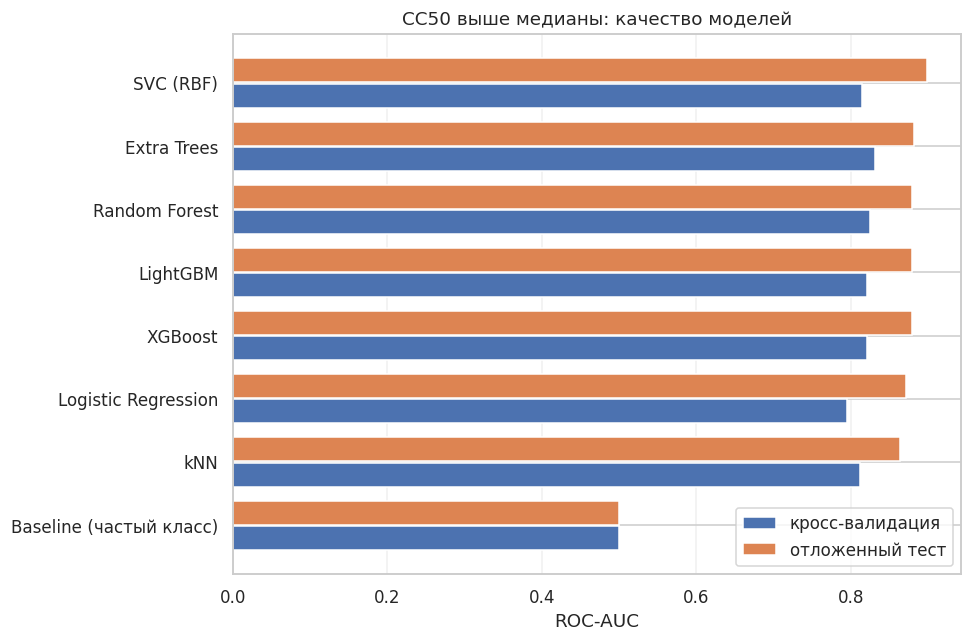

In [7]:
mdl.plot_cv_vs_test(
    cv_table, test_table, "CV roc_auc", "ROC-AUC",
    "CC50 выше медианы: качество моделей",
    save_path=FIG_DIR / "cc50_clf_models_comparison.png",
)

## 5. ROC и PR-кривые

- ROC-кривая показывает поведение модели при всех порогах
- PR-кривая информативнее при дисбалансе классов, поскольку не «вознаграждает» модель за правильное определение многочисленного отрицательного класса

Лучшая модель на тесте: SVC (RBF)


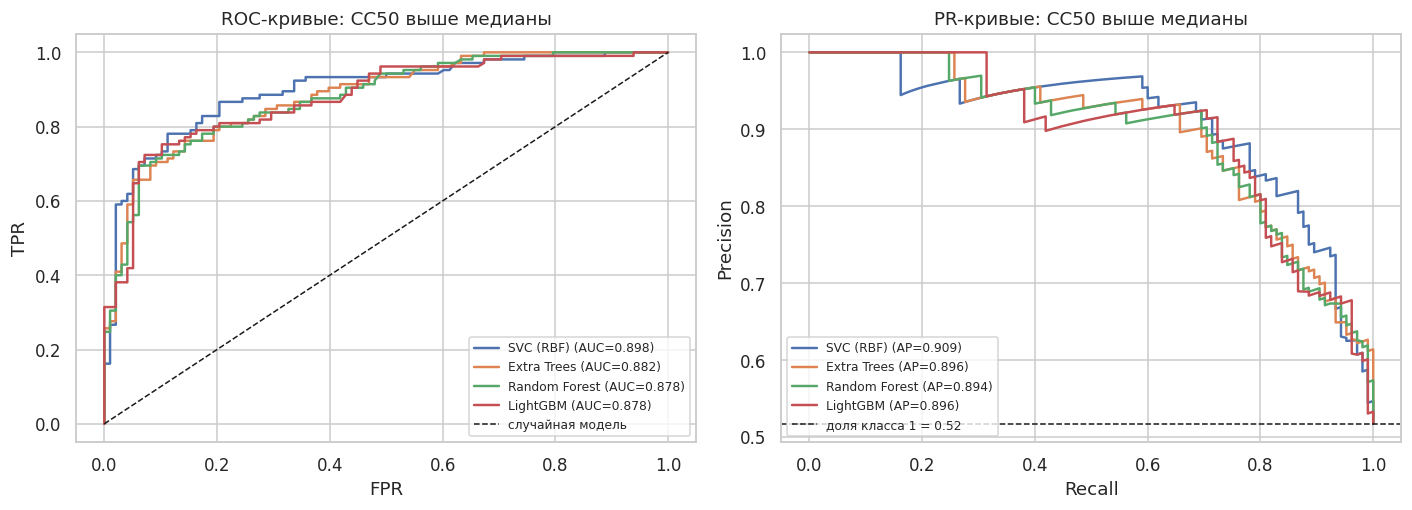

In [8]:
best_name = test_table.iloc[0]["модель"]
best_model = fitted[best_name]
print(f"Лучшая модель на тесте: {best_name}")

top_names = [n for n in test_table["модель"].head(4)]
curves = {n: fitted[n].predict_proba(X_test)[:, 1] for n in top_names}
mdl.plot_classification_diagnostics(
    y_test.to_numpy(), curves, "CC50 выше медианы",
    save_path=FIG_DIR / "cc50_clf_roc_pr.png",
)

## 6. Матрица ошибок и выбор порога

Оптимальный по F1 порог (подобран на train): 0.47


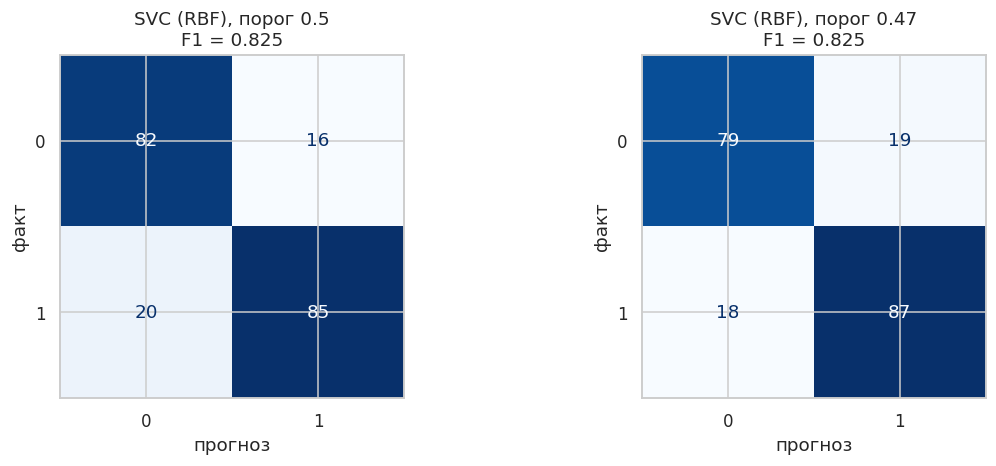

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, f1_score

proba_train = best_model.predict_proba(X_train)[:, 1]
grid = np.linspace(0.05, 0.95, 91)
f1_scores = [f1_score(y_train, (proba_train >= t).astype(int)) for t in grid]
best_threshold = float(grid[int(np.argmax(f1_scores))])
print(f"Оптимальный по F1 порог (подобран на train): {best_threshold:.2f}")

proba_test = best_model.predict_proba(X_test)[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, threshold, label in [
    (axes[0], 0.5, "порог 0.5"),
    (axes[1], best_threshold, f"порог {best_threshold:.2f}"),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, (proba_test >= threshold).astype(int), ax=ax,
        colorbar=False, cmap="Blues",
    )
    ax.set_title(f"{best_name}, {label}\n"
                 f"F1 = {f1_score(y_test, (proba_test >= threshold).astype(int)):.3f}")
    ax.set_xlabel("прогноз")
    ax.set_ylabel("факт")
plt.tight_layout()
plt.savefig(FIG_DIR / "cc50_clf_confusion.png", dpi=140, bbox_inches="tight")
plt.show()

## 7. Какие дескрипторы определяют прогноз

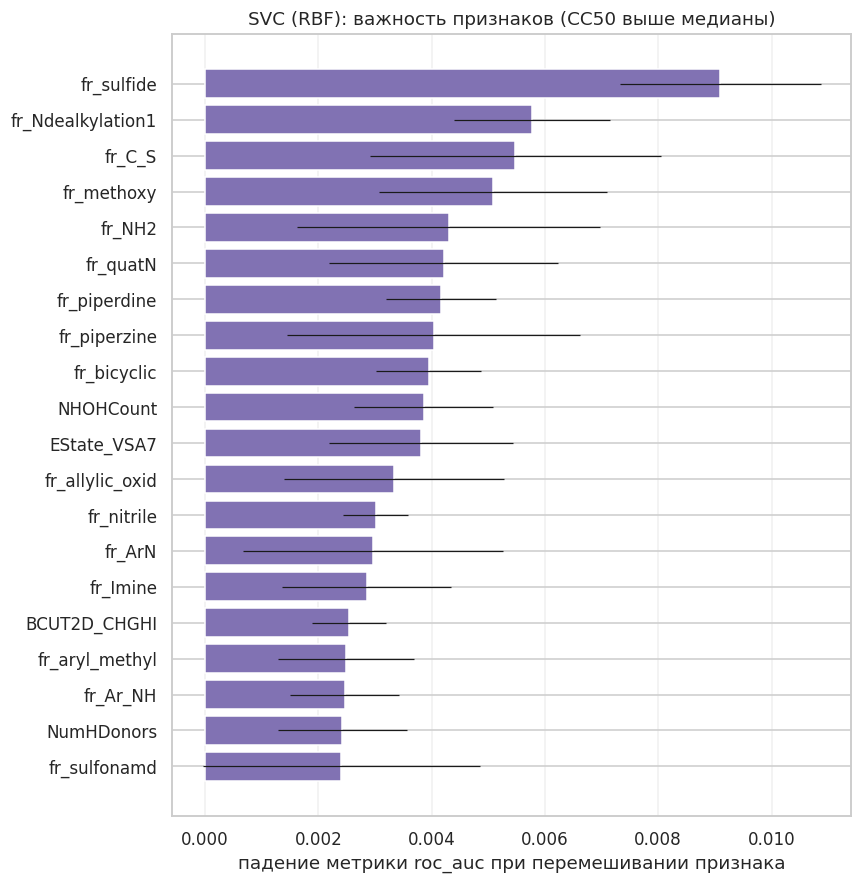

,признак,падение качества,std
0,fr_sulfide,0.0091,0.0018
1,fr_Ndealkylation1,0.0058,0.0014
2,fr_C_S,0.0055,0.0026
3,fr_methoxy,0.0051,0.0020
4,fr_NH2,0.0043,0.0027
5,fr_quatN,0.0042,0.0020
6,fr_piperdine,0.0042,0.0010
7,fr_piperzine,0.0040,0.0026
8,fr_bicyclic,0.0039,0.0009
9,NHOHCount,0.0039,0.0012


In [10]:
importance = mdl.plot_permutation_importance(
    best_model, X_test, y_test, scoring="roc_auc",
    title=f"{best_name}: важность признаков (CC50 выше медианы)",
    save_path=FIG_DIR / "cc50_clf_importance.png",
)
display(importance.head(15).round(4))
importance.to_csv(RES_DIR / "cc50_clf_importance.csv", index=False)

## 8. Устойчивость результата

In [11]:
from sklearn.metrics import roc_auc_score

stability = mdl.stability_check(
    best_model, features, target, groups,
    scoring=lambda y_true, model, X: roc_auc_score(
        y_true, model.predict_proba(X)[:, 1]),
)
display(stability.round(4))

Среднее = 0.8174, std = 0.0150, размах = 0.0376


,seed,метрика
0,0,0.7981
1,1,0.8285
2,2,0.8357
3,3,0.8150
4,4,0.8096


## 9. Выводы по задаче «CC50 > медианы»

### Что показали модели

| Наблюдение | Интерпретация |
|---|---|
| **Лучший результат среди всех семи задач**: CV ROC-AUC ≈ 0.83, на тесте до 0.90 | Цитотоксичность предсказуема заметно лучше противовирусной активности |
| На тесте вперёд выходит SVC с RBF-ядром (0.898), опережая ансамбли деревьев | Граница между классами достаточно гладкая; это согласуется с тем, что CC50 определяется непрерывными физико-химическими свойствами. По кросс-валидации SVC уступает Extra Trees, поэтому разницу на одном разбиении не следует переоценивать |
| Логистическая регрессия достигает ROC-AUC 0.87 на тесте, отставая от лидера менее чем на 0.03 | Сильнейший аргумент в пользу того, что в цитотоксичности присутствует выраженная линейная составляющая |
| Точность классификации ≈ 0.80–0.82 при сбалансированных классах | Каждое пятое предсказание ошибочно — достаточно для приоритизации, недостаточно для отказа от эксперимента |

### Практическое применение

самая надёжная моделька из всех, что мы построили, и внедрять стоит именно её, самый выгодный сценарий, отсеивать заведомо токсичные соединения ещё до синтеза. Токсичность частая причина провала на поздних стадиях

## Рекомендация

В качестве основной модели берём Extra Trees (показала себя лучше всех на кросс-валидации). SVC с RBF-ядром используем как вторую модель в ансамбле или для перекрёстной проверки


